# Исследовательский анализ рынка заведений в Москве

- Автор: Агансонов Руслан
- Дата: 09.04

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ рынка заведений в Москве с выявлением наиболее подходящего места для открытия заведения общественного питания.  

### Описание данных

Для анализа поступили данные о клиентах банка «Метанпром». Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение (например Центральный административный округ);
- `category` — категория заведения (например «кафе», «пиццерия» или «кофейня»);
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;
- `seats` — количество посадочных мест..

### Описание датасета `rest_price`

- `price` — категория цен в заведении (например «средние», «ниже среднего»);
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона (например «Средний счёт: 1000–1500 ₽»);
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:

### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними


Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух соответствующих переменных.

In [1]:
# Стандартные библиотеки Python (если понадобятся, например, для регулярных выражений или дат)
import re
from datetime import datetime

# Сторонние библиотеки для работы с данными
import pandas as pd
import numpy as np

# Библиотека для расчёта коэффициента корреляции phi_k
# Если не установлен phik нужно раскомментировать строчку ниже
#!pip install phik -U
from phik import phik_matrix

# Библиотеки для статической визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для интерактивной визуализации данных
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Выгружаем данные в переменные rest_info и rest_price
rest_info = pd.read_csv('/datasets/rest_info.csv')
rest_price = pd.read_csv('/datasets/rest_price.csv')

Познакомимся с данными датасетов `rest_info.csv` и `rest_price.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [7]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов изначально приведены к нужному формату.
- Представленные данные содержат числовые и строковые значения, которые хранятся в типах данных `int64`, `float64` или `object`.  Значения в столбцах `id`, `name`, `category`, `address`, `district` и `hours` представлены в виде строк. Часть их них характеризируют какую-либо категорию — тип данных для таких столбцов можно оптимизировать.
- Пропуски содержатся в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о клиентах банка. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов изначально приведены к нужному формату.
- Типы данных соответствуют содержимому. Тип данных для столбца `price` можно привести к категориям, в связи с ограниченностью набора данных в столбце.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные хорошего качества — в них практически нет пропущенных значений, а сами данные соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.

### Подготовка единого датафрейма

Задача проекта предполагает анализ различных районов в Москве для обнаружения наиболее подходящего места для открытия заведения общественного питания. Поэтому можно соединить данные с информацией о заведениях из таблицы `rest_info`, с информацией о среднем чеке в данных заведениях из таблицы `rest_price.csv`.

Каждая строка в этих датафреймах — это информация о заведении "общепита", поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору заведения. При соединении оставим только полные данные — это значит, что значение `id` заведения должно быть в двух датафреймах.

Соединим данные, используя значение параметра `how` по умолчанию — `'inner'`. Это позволит оставить только полные данные по заведениям в Москве.

In [9]:
# Соединяем данные в единый датафрейм res_df
res_df = rest_info.merge(rest_price, how='left', on='id')

In [10]:
# Выводим первые строки датафрейма
res_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [11]:
# Выводим информацию о датафрейме
res_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:

In [12]:
# Выводим названия столбцов датафрейма res_df
res_df.columns

Index(['id', 'name', 'category', 'address', 'district', 'hours', 'rating',
       'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill',
       'middle_coffee_cup'],
      dtype='object')

Все названия столбцов приведены к единому формату SnakeCase. Приступим к оптимизации типов данных. Понадобится провести оптимизацию целочисленных данных и некоторые строковые данные привести к типу `category`.

Для оптимизации будем использовать метод `pd.to_numeric` с аргументом `downcast='integer'`, а для изменения типа данных метод `astype` с аргументом `category`:

In [13]:
# Оптимизируем целочисленный тип данных в датафрейме res_df
res_df['chain'] = pd.to_numeric(res_df['chain'], downcast='integer')

In [14]:
#Проверяем количество уникальных строк в строковых столбцах
dict_unique = dict()
for column in ['name','category','address',
               'district','hours','price', 'avg_bill']:
    dict_unique[column] = res_df[column].nunique()
dict_unique

{'name': 5614,
 'category': 8,
 'address': 5753,
 'district': 9,
 'hours': 1307,
 'price': 4,
 'avg_bill': 897}

Из вывода заметим, что столбцы `category`, `district`, `price` можно привести к типу данных `category`, в связи с ограниченностью набора данных в столбцах:

In [15]:
#Оптимизируем категориальный тип данных
for column in ['category', 'district', 'price']:
    res_df[column] = res_df[column].astype('category')

In [16]:
#Проверим типы данных в датафрейме res_df с помощью метода info():
res_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   category
 3   address            8406 non-null   object  
 4   district           8406 non-null   category
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   int8    
 8   seats              4795 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(3), float64(4), int8(1), object(5)
memory usage: 690.5+ KB


Изучим пропущенные значения в данных: посчитаем количество в каждом столбце датафрейме, изучим данные с пропущенными значениями и сформируем гипотезы их появления. Также проведем обработку пропущенных значений.

При первичном анализе мы обнаружили пропуски в нескольких столбцах (`hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup`) датафреймов `rest_info` и `rest_price`. Узнаем абсолютное и относительное количество пропусков в этих столбцах.

In [17]:
# Применяем метод isna() к датафрейму res_df
res_df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [18]:
# Подсчитываем долю строк с пропусками
res_df.isna().sum() / res_df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В данных наблюдаются пропуски в следующих столбцах:
- `hours`: в 536 строках (6.3% данных) отсутствует информация о днях и часах работы. Процент пропусков достаточно существенен для удаления пустых строк из датасет. Возможно у данных заведений не указаны часы работы на их точке на карте, либо они работают круглосуточно. Оставим данные пропуски без изменения.
- `seats`: в 3611 строках (42.9% данных) отсутствует информация о количестве посадочных мест. Пропуски в этом столбце могут повлиять на анализ максимальной посадки в данных заведениях. Возможно, пропуски в этом поле связаны с тем, что данные заведения не предусматривают посадку людей (Фастфуд) и количество посадочных мест принимается за 0. Однако для избежания дальнейшей путаницы заменять пропуски на число 0 не будем.
- `price`: в 5091 строках (60.5% данных) отсутствуют данные о категории цен в заведении. Это один из ключевых параметров, влияющих на анализ аудитории, которые выбирают данные места. Процент пропусков высок для того, чтобы исключить пустые данные из датасета. Однако возможно определить категорию заведения на основании следущего поля `avg_bill`.
- `avg_bill`: в 4590 строках (54.6% данных) отсутствует информация о средней стоимости заказа. Для половины заведений изначально не было этой информации в датасете. Также причиной может быть что в данных заведениях все выполняется "под заказ" и средний чек невозможно посчитать привычным способом.  
- `middle_avg_bill`: в 5257 строках (62.5% данных) отсутствует информация об оценке среднего чека. Для половины заведений изначально не было этой информации в датасете. Однако, пропуски в этом столбце подразумеваются из описания данного столбца (число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»).
- `middle_coffee_cup`: в 7871 строках (93.6% данных) отсутствует информация об оценке одной чашки капучино. Для половины заведений изначально не было этой информации в датасете. Однако, пропуски в этом столбце подразумеваются из описания данного столбца (число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»).


Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [19]:
# Проверяем полные дубликаты в датафрейме res_df
res_df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [20]:
res_df.duplicated(subset='id').sum()

0

Тут тоже всё хорошо — каждая строка соответствует уникальному клиенту. Теперь проверим корректность написания категориальных значений данных `res_df`.

In [21]:
res_df['category'].unique()

['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']
Categories (8, object): ['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб', 'быстрое питание', 'булочная', 'столовая']

In [22]:
res_df['district'].unique()

['Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Западный административный округ', 'Центральный административный округ', 'Восточный административный округ', 'Юго-Восточный административный округ', 'Южный административный округ', 'Юго-Западный административный округ']
Categories (9, object): ['Северный административный округ', 'Северо-Восточный административный округ', 'Северо-Западный административный округ', 'Западный административный округ', ..., 'Восточный административный округ', 'Юго-Восточный административный округ', 'Южный административный округ', 'Юго-Западный административный округ']

In [23]:
res_df['price'].unique()

[NaN, 'выше среднего', 'средние', 'высокие', 'низкие']
Categories (4, object): ['выше среднего', 'средние', 'высокие', 'низкие']

Все категории хранят уникальные значения для каждой из категорий.

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [24]:
#Создадим столбец is_24_7 с помощью равенства:
res_df['is_24_7'] = res_df['hours'] == 'ежедневно, круглосуточно'

---

### Промежуточный вывод

На этом предобработка завершена. Предоставленные данные хорошего качества и требуют не так много действий по предобработке. Однако, независимо от качества данных, завершим этот этап небольшим промежуточным выводом:

В результате предобработки данных были выполнены следующие действия:

- Скорректированы типы данных нескольких строковых столбцов — их привели к `category`, а для одного числового столбца был понижен разряд типа данных для более быстрой работы;
- В представленном датасете выявлены пропуски различного характера: от небольших в `hours` до системных в `seats`, `price` и расчетных полях чеков. Рекомендуется заполнить `seats` нулями, восстановить категории цен через `avg_bill`, а остальные пустые значения рассматривать как структурную особенность данных, обусловленную спецификой заведений.
- Данные проверили на явные и неявные дубликаты — в данных их нет.

---

## 3. Исследовательский анализ данных

Проведем исследовательский анализ исходных данных.


---

### Задача 1

Исследуем какие категории заведений представлены в данных, а также количество объектов общественного питания по каждой категории.

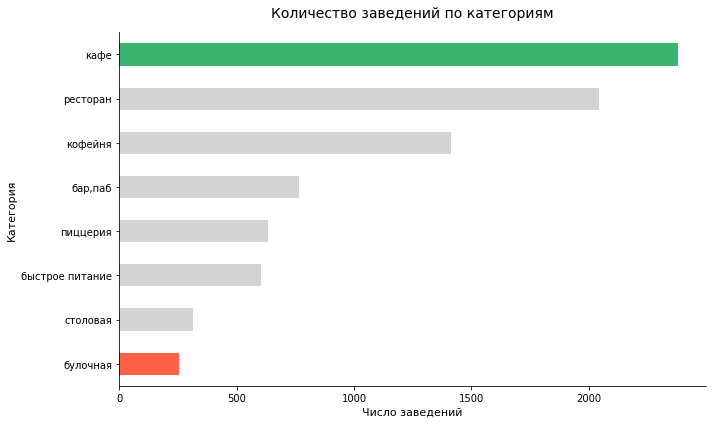

In [56]:
#Сгруппируем данные по категории заведения и выведем линейчатую диаграмму распределения:
category_counts = res_df.groupby('category')['id'].count().sort_values()
#Определим цвета для наименее и наиболее популярных категорий (минимум и максимум)
colors = ['lightgrey'] * len(category_counts)
colors[0] = 'tomato'           # Самая редкая категория
colors[-1] = 'mediumseagreen'  # Самая частая категория
#Визуализируем
ax = category_counts.plot(kind='barh', color=colors, figsize=(10, 6))
ax.set_title('Количество заведений по категориям', fontsize=14, pad=15)
ax.set_xlabel('Число заведений', fontsize=11)
ax.set_ylabel('Категория', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Из категорий заведений значительно преобладает - кафе (около 2300 заведений), а наиболее не распространненной категорией является булочная (около 200 заведений).

---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

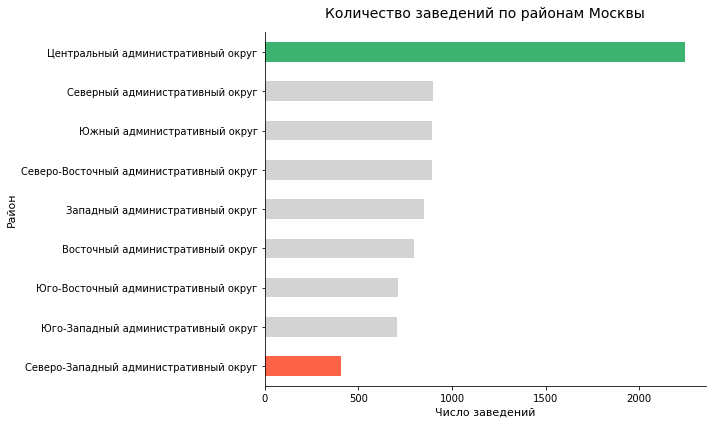

In [49]:
#Сгруппируем данные по району заведения и выведем линейчатую диаграмму распределения:
district_counts = res_df.groupby('district')['id'].count().sort_values()
#Определим цвета для лучшего и худшего районов
colors = ['lightgrey'] * len(district_counts)
colors[0] = 'tomato'
colors[-1] = 'mediumseagreen'
#Визуализируем
ax = district_counts.plot(kind='barh', color=colors, figsize=(10, 6))
ax.set_title('Количество заведений по районам Москвы', fontsize=14, pad=15)
ax.set_xlabel('Число заведений', fontsize=11)
ax.set_ylabel('Район', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Из визуализации видно, что наибольшее количество заведений находятся в Центральном административном округе. Рассмотрим данный район более подробно:

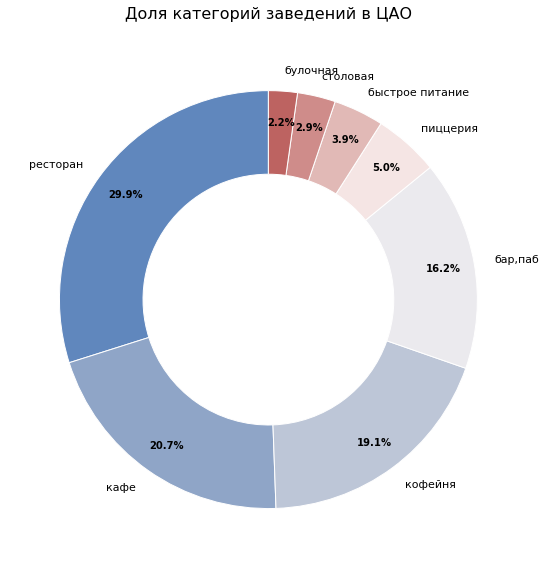

In [97]:
#Группируем данные и сортируем по убыванию
cao_df = res_df[res_df['district'] == 'Центральный административный округ']
category_counts_cao = cao_df.groupby('category')['id'].count().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
#Работа с цветами 
colors = sns.color_palette('vlag', n_colors=len(category_counts_cao))
#Визуализируем кольцевую диаграмму
wedges, texts, autotexts = plt.pie(
    category_counts_cao, 
    labels=category_counts_cao.index, 
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85, 
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.setp(autotexts, size=10, weight="bold")
plt.setp(texts, size=11)
plt.title('Доля категорий заведений в ЦАО', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Из данной диаграммы заметим, что сохраняется почти та же тенденция - наиболее популярными категориям являются ресторан и кафе, а самой не открываемой - булочная. Однако есть и изменения, в данном районе в среднем больше баров(пабов), чем в целом по Москве.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

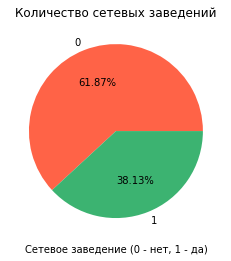

In [60]:
#Сгруппируем данные по категории заведения и выведем круговую диаграмму распределения:
ax = res_df.groupby('chain')['id'].count().plot(kind='pie', colors=['tomato', 'mediumseagreen'], autopct='%1.2f%%')
ax.set_title('Количество сетевых заведений')
ax.set_xlabel('Сетевое заведение (0 - нет, 1 - да)')
ax.set_ylabel('')
plt.show()

Количество не сетевых заведений в Москве превосходит количество сетевых. Однако рассмотрим распределение сетевых точек в зависимости от категории:

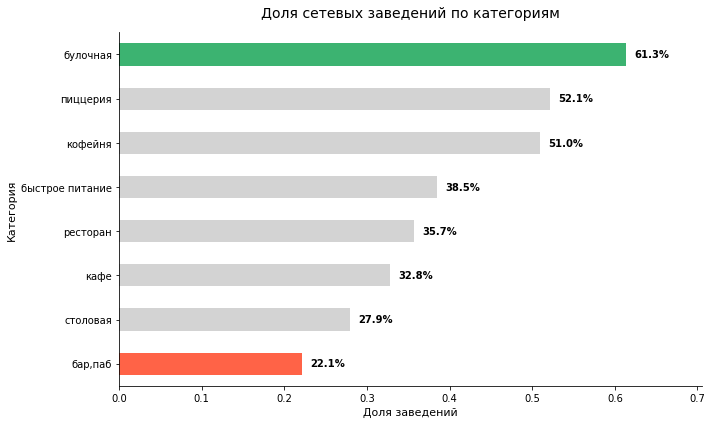

In [64]:
#Группируем данные и считаем долю сетевых заведений
chain_proportions = res_df.groupby('category')['chain'].mean().sort_values()
#Определяем цвета
colors = ['lightgrey'] * len(chain_proportions)
colors[0] = 'tomato'           # Категория с наименьшей долей сетей
colors[-1] = 'mediumseagreen'  # Категория с наибольшей долей сетей
#Визуализируем
ax = chain_proportions.plot(kind='barh', figsize=(10, 6), color=colors)
#Добавляем подписи данных
for i, v in enumerate(chain_proportions):
    ax.text(v + 0.01, i, f'{v*100:.1f}%', va='center', fontweight='bold', fontsize=10)
ax.set_title('Доля сетевых заведений по категориям', fontsize=14, pad=15)
ax.set_xlabel('Доля заведений', fontsize=11)
ax.set_ylabel('Категория', fontsize=11)
ax.set_xlim(0, chain_proportions.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Чаще всего сетевыми заведениями в Москве являются булочные, наиболее реже всего по сети открываются бары и пабы, что является более локальным бизнесом в городе.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. А также, приведем для каждой категории заведений наиболее типичное для него значение.

In [30]:
#Вызовем метод describe() для просмотра описания распределения данных для столбца seats:
res_df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Заметим, что среднее арифметическое больше чем медиана, что означает что распределение подвержено выбросам и смещено влево. Выведем визуализацию распределения с помощью графика:

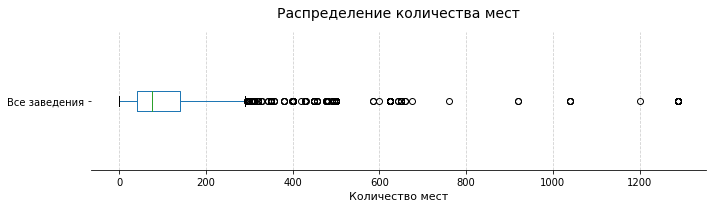

In [73]:
#Выведем распределение количества мест:
ax = res_df['seats'].plot(kind='box', vert=False, figsize=(10, 3))
ax.set_title('Распределение количества мест', fontsize=14, pad=15)
ax.set_xlabel('Количество мест', fontsize=11)
ax.set_yticklabels(['Все заведения'])
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

Гипотеза о выбросах и смещенном распределении подтвердилась. Аномальные значения с числом посадочных мест скорее всего связаны с учетом мест всего фудкорта либо уникальностью заведения. Рассмотрим распеределение наиболее типичного количества мест для каждой из категорий:

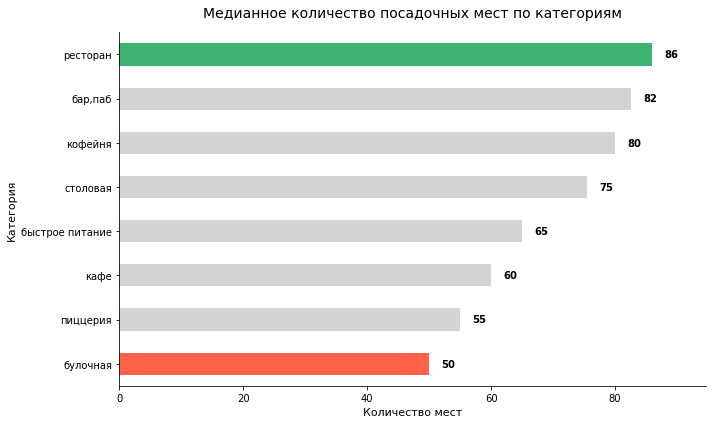

In [75]:
median_seats = res_df.groupby('category')['seats'].median().sort_values()
#Определяем цвета
colors = ['lightgrey'] * len(median_seats)
colors[0] = 'tomato'           # Категория с наименьшей вместимостью
colors[-1] = 'mediumseagreen'  # Категория с наибольшей вместимостью
#Визуализируем график
ax = median_seats.plot(kind='barh', figsize=(10, 6), color=colors)
#Добавляем подписи данных
for i, v in enumerate(median_seats):
    ax.text(v + 2, i, f'{int(v)}', va='center', fontweight='bold', fontsize=10)
ax.set_title('Медианное количество посадочных мест по категориям', fontsize=14, pad=15)
ax.set_xlabel('Количество мест', fontsize=11)
ax.set_ylabel('Категория', fontsize=11)
ax.set_xlim(0, median_seats.max() * 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Наибольшая вместимость характерна для ресторанов и баров/пабов (в среднем 75–85 мест), в то время как булочные и пиццерии показывают минимальные значения — около 50 мест. Остальные типы заведений демонстрируют средние показатели в диапазоне 60–70 посадочных мест.

---

### Задача 5

Исследуем рейтинг заведений. Рассмотрим, сильно ли различаются усреднённые рейтинги для разных типов общепита?

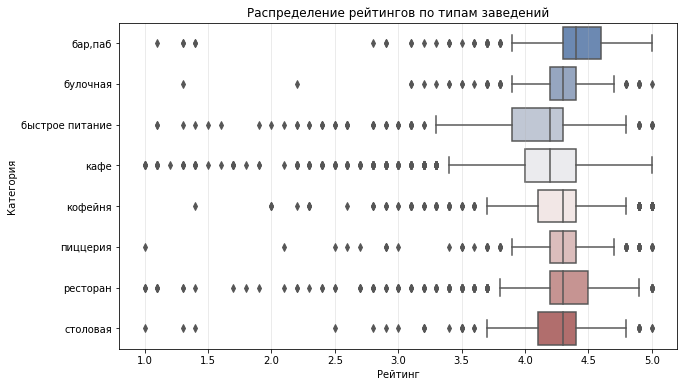

In [33]:
#Выведем распределение рейтингов для каждого из заведений
plt.figure(figsize=(10, 6))
sns.boxplot(data=res_df, x='rating', y='category', palette='vlag')
plt.title('Распределение рейтингов по типам заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x', alpha=0.3)

Из данных распределений можно заметить, что наибольшее количество выбросов (плохих оценок) чаще всего наблюдается в кафе, ресторанах и фастфуде. А наименьшее количество отличных от средних оценок значений находятся в булочных и барах.

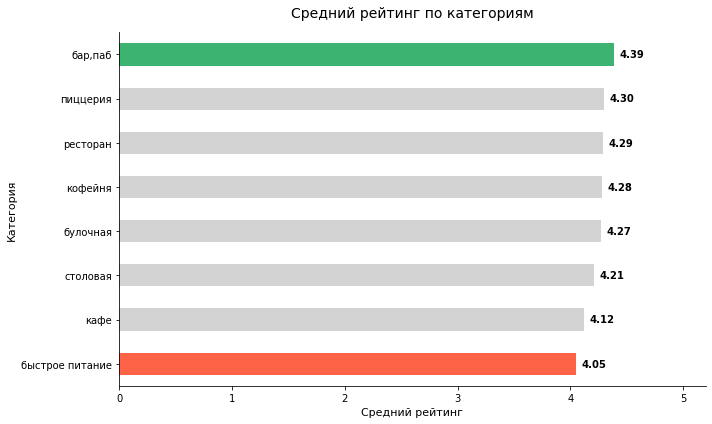

In [77]:
#Группируем данные
avg_ratings = res_df.groupby('category')['rating'].mean().sort_values()
#Определяем цвета
colors = ['lightgrey'] * len(avg_ratings)
colors[0] = 'tomato'
colors[-1] = 'mediumseagreen'
#Визуализируем график
ax = avg_ratings.plot(kind='barh', figsize=(10, 6), color=colors)
#Добавляем подписи данных
for i, v in enumerate(avg_ratings):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=10)
ax.set_title('Средний рейтинг по категориям', fontsize=14, pad=15)
ax.set_xlabel('Средний рейтинг', fontsize=11)
ax.set_ylabel('Категория', fontsize=11)
ax.set_xlim(0, 5.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Усреднённые рейтинги различаются незначительно, так как показатели всех категорий находятся в узком диапазоне от 4.05 до 4.39 баллов. Лидерами являются бары и пабы, однако общий разрыв между ними и фастфудом составляет менее 0.4 пункта, что говорит об отсутствии критической разницы.

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

In [35]:
# Сохраняем матрицу корреляции признака raing с другими признаками клиента
correlation_matrix = res_df[['rating', 'category', 'district', 'chain', 'seats', 'is_24_7', 'price']].phik_matrix()
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating
price,0.220295
district,0.200691
category,0.190003
is_24_7,0.150173
chain,0.108092
seats,0.000000


Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорией (`0.22`), географического положения района (`0.2`) и типа заведений (`0.19`). Для остальных признаков коэффициент корреляции снижается с `0.15` до `0`. Изучим, существует ли зависимость между ценовой категорией и рейтингом заведения. Для этого построим столбчатые диаграммы с разделением по признаку `rating` среди разных ценовых сегментов:

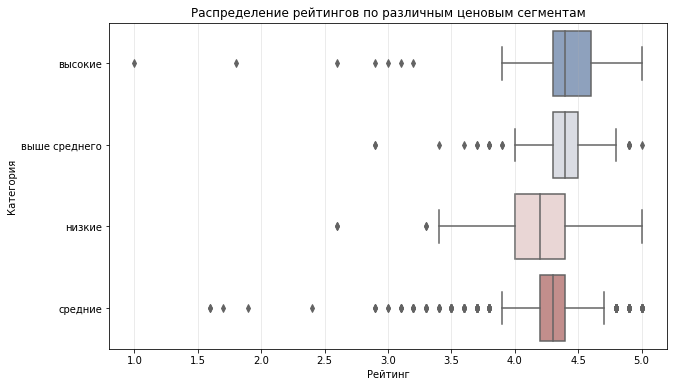

In [36]:
#Выведем распределение рейтингов для каждого из заведений
plt.figure(figsize=(10, 6))
sns.boxplot(data=res_df, x='rating', y='price', palette='vlag')
plt.title('Распределение рейтингов по различным ценовым сегментам')
plt.xlabel('Рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x', alpha=0.3)

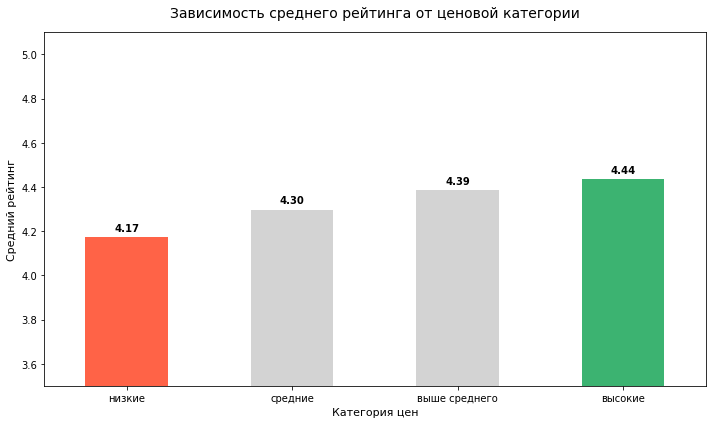

In [79]:
#Группируем и сортируем данные
avg_ratings_by_price = res_df.groupby('price')['rating'].mean().sort_values()
#Создаем массив цветов
colors = ['lightgrey'] * len(avg_ratings_by_price)
colors[0] = 'tomato'
colors[-1] = 'mediumseagreen'
#Строим график
ax = avg_ratings_by_price.plot(kind='bar', figsize=(10, 6), color=colors, rot=0)
ax.set_ylim(3.5, 5.1)

#Добавляем точные значения над столбцами
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center',
                va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontweight='bold',
                fontsize=10)
ax.set_title('Зависимость среднего рейтинга от ценовой категории', fontsize=14, pad=15)
ax.set_xlabel('Категория цен', fontsize=11)
ax.set_ylabel('Средний рейтинг', fontsize=11)
plt.tight_layout()
plt.show()

При анализе самой сильной корреляции с помощью визуализации прослеживается прямая корреляция: средний рейтинг заведений стабильно растет при переходе от бюджетного ценового сегмента к премиальному. Анализ распределения подтверждает, что в категориях с более высокими ценами оценки более стабильны и сосредоточены в верхней части шкалы, в то время как сегмент с низкими ценами отличается наибольшим разбросом и более низким медианным значением.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга.

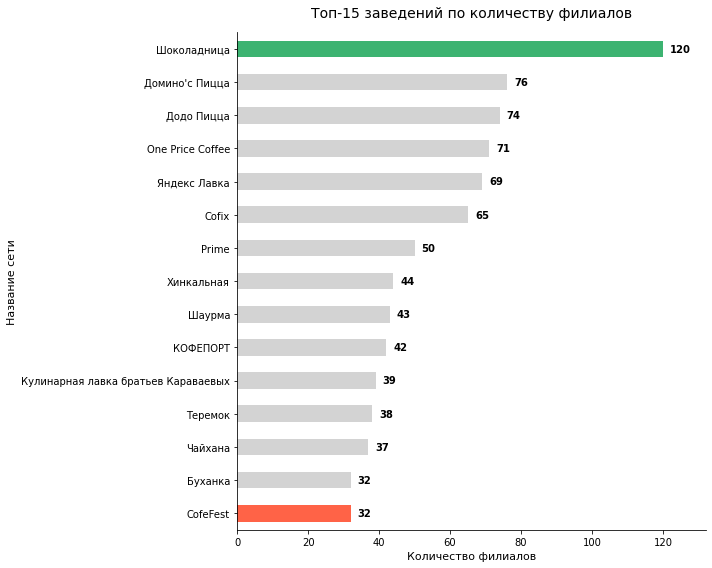

In [81]:
#Фильтруем данные и находим топ-15
#Сортируем по возрастанию и берем последние 15
top_15 = res_df[(res_df['name'] != 'Кафе') & (res_df['name'] != 'Ресторан')] \
    .groupby('name')['address'].count().sort_values(ascending=True).tail(15)
#Определяем цвета
colors = ['lightgrey'] * len(top_15)
colors[0] = 'tomato'
colors[-1] = 'mediumseagreen'
#Строим горизонтальную диаграмму
ax = top_15.plot(kind='barh', figsize=(10, 8), color=colors)
#Добавляем точные цифры
for i, v in enumerate(top_15):
    ax.text(v + 2, i, f'{int(v)}', va='center', fontweight='bold', fontsize=10)
ax.set_title('Топ-15 заведений по количеству филиалов', fontsize=14, pad=15)
ax.set_xlabel('Количество филиалов', fontsize=11)
ax.set_ylabel('Название сети', fontsize=11)
ax.set_xlim(0, top_15.max() * 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Наиболее распространенными сетевыми заведениями являются: Додо Пицца и Домино'с Пицца - у них более 70 точек по всей Москве, а лидером является Шоколадница - более 120 заведений. Рассмотрим среднюю оценку для каждого из 15 мест:

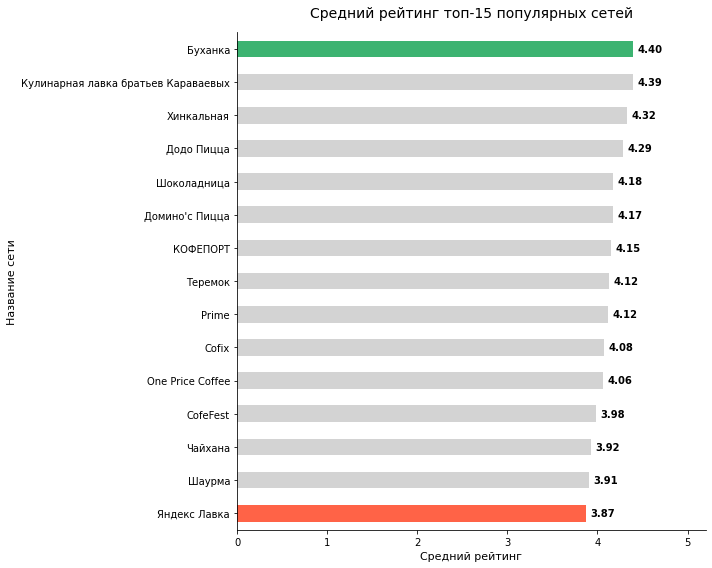

In [83]:
#Рассчитываем средний рейтинг для топ-15 сетей и сортируем
avg_ratings_top15 = res_df[res_df['name'].isin(top_15.index)].groupby('name')['rating'].mean().sort_values()
#Задаем нашу палитру
colors = ['lightgrey'] * len(avg_ratings_top15)
colors[0] = 'tomato'
colors[-1] = 'mediumseagreen'
#Строим график
ax = avg_ratings_top15.plot(kind='barh', figsize=(10, 8), color=colors)
#Добавляем точные значения рейтинга рядом со столбцами
for i, v in enumerate(avg_ratings_top15):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=10)
ax.set_title('Средний рейтинг топ-15 популярных сетей', fontsize=14, pad=15)
ax.set_xlabel('Средний рейтинг', fontsize=11)
ax.set_ylabel('Название сети', fontsize=11)
ax.set_xlim(0, 5.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Из визуализации видно, что наиболее успешные у пользователей места имееют меньше всего точек из списка топ-15. А разница между самым рекомендуемым и "провальным" заведением составляет больше 0.5 пунктов рейтинга, что довольно таки существенно для одних из самых распространенных мест в Москве. Рассмотрим распределение категорий заведений для этого списка:

In [40]:
#Рассмотрим распределение категорий заведений с помощью сводной таблицы:
category_pivot = res_df[res_df['name'].isin(top_15.index)].pivot_table(
    index='category',
    values='name',
    aggfunc='count' 
).sort_values(by='name', ascending=False)

# Переименуем столбец для наглядности
category_pivot.columns = ['Количество заведений']
category_pivot

,Количество заведений
category,
кофейня,334
ресторан,178
пиццерия,150
кафе,98
быстрое питание,42
булочная,26
"бар,паб",3
столовая,1


Большая часть популярных сетевых точек приходится на кофейни и рестораны, которые заметно отрываются от остальных категорий по количеству заведений. Другие форматы, такие как столовые и бары и пабы, в этом списке лидеров практически не представлены.

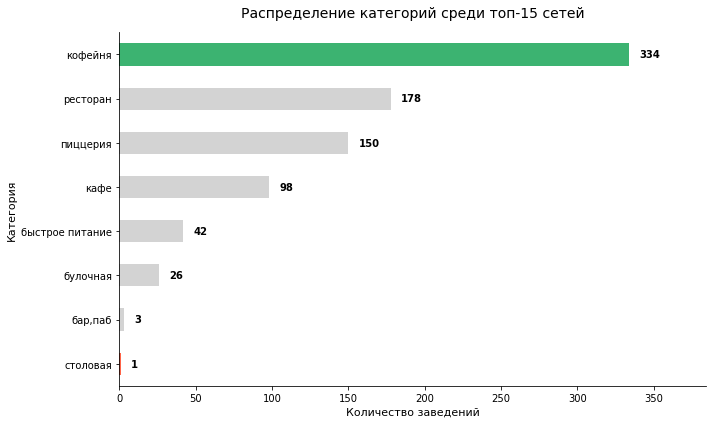

In [85]:
#Группируем данные, считаем количество и фильтруем нули
category_top_15 = res_df[res_df['name'].isin(top_15.index)].groupby('category')['name'].count()
category_top_15 = category_top_15[category_top_15 > 0].sort_values()
#Задаем цвета 
colors = ['lightgrey'] * len(category_top_15)
colors[0] = 'tomato'
colors[-1] = 'mediumseagreen'
#Строим график
ax = category_top_15.plot(kind='barh', figsize=(10, 6), color=colors)
#Добавляем точные цифры
for i, v in enumerate(category_top_15):
    offset = category_top_15.max() * 0.02
    ax.text(v + offset, i, f'{int(v)}', va='center', fontweight='bold', fontsize=10)
ax.set_title('Распределение категорий среди топ-15 сетей', fontsize=14, pad=15)
ax.set_xlabel('Количество заведений', fontsize=11)
ax.set_ylabel('Категория', fontsize=11)
ax.set_xlim(0, category_top_15.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Чаще всего крупные сети — это кофейни и рестораны, а больше всего точек открыли «Шоколадница» и «Додо Пицца». При этом самый высокий рейтинг среди всех лидеров у «Буханки», а самый низкий — у ресторана «Яндекс Лавка».

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Рассмотрим как удалённость от центра влияет на цены в заведениях?


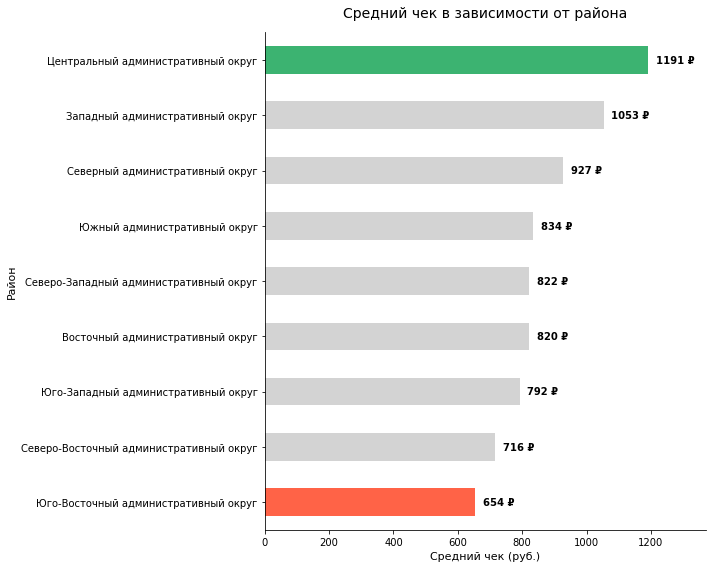

In [87]:
#Группируем данные, считаем средний чек и сортируем
avg_bill_by_district = res_df.groupby('district')['middle_avg_bill'].mean().sort_values()
# Создаем массив цветов
colors = ['lightgrey'] * len(avg_bill_by_district)
colors[0] = 'tomato'           # Район с самым низким средним чеком
colors[-1] = 'mediumseagreen'  # Район с самым высоким средним чеком
#Визуализируем график
ax = avg_bill_by_district.plot(kind='barh', figsize=(10, 8), color=colors)
#Добавляем точные значения среднего чека прямо на график
for i, v in enumerate(avg_bill_by_district):
    offset = avg_bill_by_district.max() * 0.02
    ax.text(v + offset, i, f'{int(v)} ₽', va='center', fontweight='bold', fontsize=10)
ax.set_title('Средний чек в зависимости от района', fontsize=14, pad=15)
ax.set_xlabel('Средний чек (руб.)', fontsize=11)
ax.set_ylabel('Район', fontsize=11)
ax.set_xlim(0, avg_bill_by_district.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Самый высокий средний чек зафиксирован в Центральном округе (около 1200 рублей), а самый низкий — в Юго-Восточном (примерно 650 рублей), что подтверждает снижение стоимости услуг по мере удаления от центра.

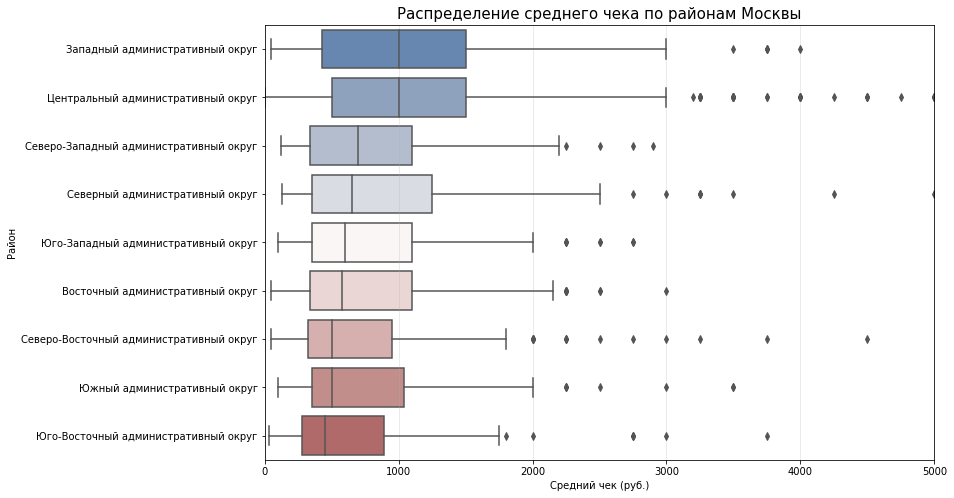

In [43]:
#Упорядочим районы по медианному чеку, чтобы график был читаемым
order = res_df.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.boxplot(data=res_df, x='middle_avg_bill', y='district', order=order, palette='vlag')

#Ограничим ось X, чтобы "выбросы" в 50 000 руб. не сжимали основные данные
plt.xlim(0, 5000) 
plt.title('Распределение среднего чека по районам Москвы', fontsize=15)
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Район')
plt.grid(axis='x', alpha=0.3)
plt.show()

Рассмотрим распределение среднего чека в ЦАО:

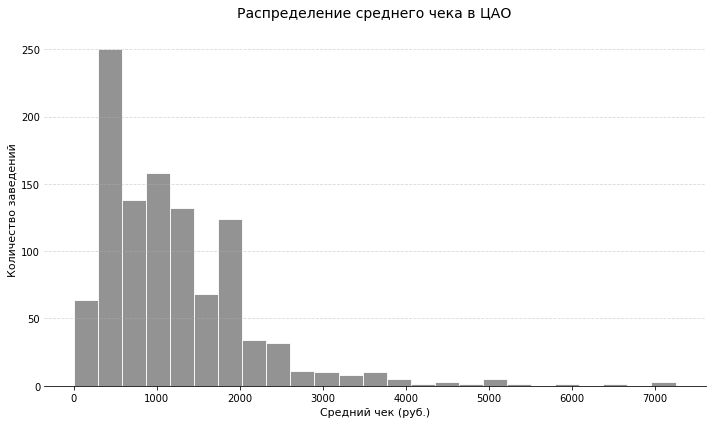

In [90]:
#Сохраняем данные по ЦАО в отдельную переменную для чистоты кода
cao_bills = res_df[res_df['district'] == 'Центральный административный округ']['middle_avg_bill']
#Строим гистограмму
ax = cao_bills.plot(kind='hist', bins=25, figsize=(10, 6), color='grey', edgecolor='white', alpha=0.85)
ax.set_title('Распределение среднего чека в ЦАО', fontsize=14, pad=15)
ax.set_xlabel('Средний чек (руб.)', fontsize=11)
ax.set_ylabel('Количество заведений', fontsize=11) # Заменили "Частоту" на бизнес-метрику
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.show()

Самые высокие цены ожидаемо наблюдаются в Центральном и Западном округах, где средний чек почти в два раза выше, чем на окраинах. Чем дальше округ находится от центра (например, Юго-Восточный или Восточный), тем ниже становится стоимость среднего чека и тем меньше в нем дорогих мест. Однако в каждом районе существует несколько заведений со средним чеком превышающим медианное значение в несколько раз.

---

### Промежуточный вывод

Анализ взаимосвязи данных показал, что:

- Из категорий заведений значительно преобладает - кафе (около 2300 заведений), а наиболее не распространненной категорией является булочная (около 50 заведений). Наибольшее количество заведений находятся в Центральном административном округе.
- Количество не сетевых заведений в Москве превосходит количество сетевых. Чаще всего сетевыми заведениями в Москве являются булочные, пиццерии и кофейни, наиболее реже всего по сети открываются бары и пабы, что является наиболее локальным бизнесом общественного питания в городе.
- Все типы заведений демонстрируют средние показатели в диапазоне 60–70 посадочных мест.
- Лидерами средний оценок на картах являются бары и рестораны, что присуще более дорогим заведениям, однако общий разрыв между ними и фастфудом составляет менее 0.4 пункта, что говорит об отсутствии критической разницы.
- При анализе самой сильной корреляции с помощью визуализации прослеживается прямая корреляция: средний рейтинг заведений стабильно растет при переходе от бюджетного ценового сегмента к премиальному.
- Чаще всего крупные сети — это кофейни, пиццерии и рестораны, а больше всего точек открыли «Шоколадница» и «Домино'c Пицца». При этом самый высокий рейтинг среди всех лидеров у «Буханки», а самый низкий — у ресторанов «Яндекс Лавки.
- Чем дальше округ находится от центра (например, Юго-Восточный или Восточный), тем ниже становится стоимость среднего чека и тем меньше в нем дорогих мест.

## 4. Итоговый вывод и рекомендации

В ходе исследования был проведён анализ рынка общественного питания Москвы на основе актуальных данных о заведениях. Мы изучили распределение объектов по типам, сетевую принадлежность, ценовую политику и территориальное расположение. Основной акцент был сделан на выявлении факторов, влияющих на успех заведения (рейтинг) и его масштаб (количество филиалов).

### Общий профиль рынка общественного питания
Анализ данных позволил сформировать общую картину индустрии в городе:

Структура собственности: Рынок характеризуется преобладанием несетевых заведений. Доля сетевых объектов составляет около 38%, что говорит о высокой конкуренции со стороны уникальных авторских концепций.

Популярные сегменты: Лидерами по количеству точек являются кафе, рестораны и кофейни. В топе крупнейших сетей доминируют бренды быстрого питания и кофе-пойнты, имеющие от 50 до 150+ филиалов.

Качество услуг: Средний рейтинг заведений в Москве находится на высоком уровне — 4.1–4.4 балла. При этом около 30–40% заведений относятся к среднему ценовому сегменту.

### Факторы, влияющие на характеристики заведений
На показатели популярности и качества заведений влияют регион регистрации (округ), ценовая категория и формат работы (сеть/не сеть):

Ценовой фактор: Наблюдается прямая зависимость — чем выше ценовая категория, тем выше средний рейтинг. У заведений категории «высокие цены» средняя оценка стабильно выше 4.4, в то время как в бюджетном сегменте она может опускаться до 4.1.

Географический фактор: Самые дорогие и высокооцененные заведения сосредоточены в ЦАО и ЗАО. В этих округах также наблюдается наибольший разрыв между средним и медианным чеком, что указывает на наличие эксклюзивных премиальных объектов.

Сетевой фактор: Сетевая модель наиболее успешна в сегментах с низким и средним чеком (фастфуд, кофейни). В сегменте высокой кухни сетевой формат представлен значительно слабее.

### Рекомендации
Для успешного запуска или развития бизнеса в сфере общепита Москвы стоит учитывать следующие рекомендации:

Для новых сетей: Оптимальными форматами для масштабирования остаются кофейни и фастфуд. При выборе локации стоит ориентироваться на спальные районы с высокой плотностью населения, где конкуренция ниже, чем в центре.

Для премиального сегмента: Необходимо фокусироваться на ЦАО, делая ставку на уникальность концепции и высокий сервис, так как в этом сегменте клиенты менее чувствительны к цене, но крайне требовательны к рейтингу.

Повышение лояльности: Заведениям среднего сегмента рекомендуется работать над качеством сервиса для преодоления порога рейтинга в 4.4 балла.